In [1]:
# Using an organized yaml file, group experiments into epochs based on structure
# The organized structure has the format:
# Epoch:
#   Train:
#     - File path 1
#   Inter:
#     - File path 2
#   Test:
#     - File path 3
# Epoch: ...
# Group data by epoch, making sure that each epoch has a train, inter, and test file within a dictionary
from experimentStruct import ExperimentStruct
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yaml

In [2]:
def process_epochs(grouped_data, colors=['blue', 'red', 'blue'], colors2=['green', 'black', 'green']):
    # plot_distance_traveled also returns a list of distances per trial, store all distance values in a matrix for statistical analysis
    train_1Hr_all = []
    inter_1Hr_all = []
    test_1Hr_all = []
    train_4Hr_all = []
    inter_4Hr_all = []
    test_4Hr_all = []
    for i, (epoch, data) in enumerate(grouped_data.items()):
        train_exp = ExperimentStruct(data['Train'][0]) if data['Train'] else None
        inter_exp = ExperimentStruct(data['Inter'][0]) if data['Inter'] else None
        test_exp = ExperimentStruct(data['Test'][0]) if data['Test'] else None

        # Split 4Hour vs 1Hour epochs described in the epoch name
        if '4Hour' in epoch:
            # print(f"Plotting Epoch: {epoch}")
            train_dist = train_exp.get_distance_traveled(normalize=train_exp.min_distance) if train_exp else None
            inter_dist = inter_exp.get_distance_traveled(normalize=inter_exp.min_distance) if inter_exp else None
            test_dist = test_exp.get_distance_traveled(normalize=train_exp.min_distance) if test_exp else None

            if train_dist is not None:
                train_4Hr_all.append(train_dist)
            if inter_dist is not None:
                inter_4Hr_all.append(inter_dist)
            if test_dist is not None:
                test_4Hr_all.append(test_dist)
            
        elif '1Hour' in epoch:
            # print(f"Plotting Epoch: {epoch}")
            train_dist = train_exp.get_distance_traveled(normalize=train_exp.min_distance) if train_exp else None
            inter_dist = inter_exp.get_distance_traveled(normalize=inter_exp.min_distance) if inter_exp else None
            test_dist = test_exp.get_distance_traveled(normalize=train_exp.min_distance) if test_exp else None
            if train_dist is not None:
                train_1Hr_all.append(train_dist)
            if inter_dist is not None:
                inter_1Hr_all.append(inter_dist)
            if test_dist is not None:
                test_1Hr_all.append(test_dist)

    train_1Hr_arr = np.array(train_1Hr_all)
    inter_1Hr_arr = np.array(inter_1Hr_all)
    test_1Hr_arr = np.array(test_1Hr_all)
    train_4Hr_arr = np.array(train_4Hr_all)
    inter_4Hr_arr = np.array(inter_4Hr_all)
    test_4Hr_arr = np.array(test_4Hr_all)
    return train_1Hr_arr, inter_1Hr_arr, test_1Hr_arr, train_4Hr_arr, inter_4Hr_arr, test_4Hr_arr

# Calculate the mean and standard error of the mean given the array and plot the mean with error bars
def plot_mean_sem(data, scatter=True, x_offset=0, color='blue'):
    # Also plot the individual data points as a scatter plot
    if scatter:
        for i in range(data.shape[0]):
            plt.scatter(np.arange(data.shape[1]) + x_offset, data[i], color=color, alpha=0.3)

    mean = np.mean(data, axis=0)
    sem = np.std(data, axis=0) / np.sqrt(data.shape[0])
    x_vals = np.arange(len(mean)) + x_offset
    plt.errorbar(x_vals, mean, yerr=sem, fmt='-o', color=color)

def plot_all_epochs(train_1Hr_arr, inter_1Hr_arr, test_1Hr_arr, train_4Hr_arr, inter_4Hr_arr, test_4Hr_arr):
    plot_mean_sem(train_1Hr_arr, x_offset=0, color='blue')
    plot_mean_sem(inter_1Hr_arr, x_offset=10, color='blue')
    plot_mean_sem(test_1Hr_arr, x_offset=30, color='blue')
    plot_mean_sem(train_4Hr_arr, x_offset=0, color='green')
    plot_mean_sem(inter_4Hr_arr, x_offset=20, color='green')
    plot_mean_sem(test_4Hr_arr, x_offset=30, color='green')

def plot_from_yaml(exp_yaml, rat):
    with open(exp_yaml, 'r') as f:
        exp_dict = yaml.safe_load(f)
    # Group data by epoch, making sure that each epoch has a train, inter, and test file within a dictionary
    grouped_data = {}
    for epoch, data in exp_dict.items():
        if 'Train' in data and 'Inter' in data and 'Test' in data and rat in epoch:
            grouped_data[epoch] = {
                'Train': data['Train'],
                'Inter': data['Inter'],
                'Test': data['Test']
            }
    
    plot_all_epochs(*process_epochs(grouped_data))

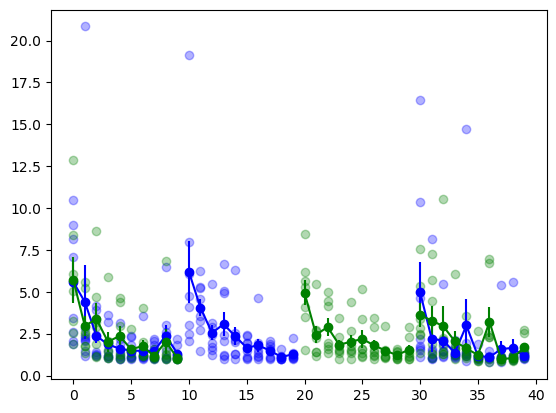

In [ ]:
# exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/FEBRUARY/experiment_organized.yaml'
# exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/MARCH/experiment_organized.yaml'
exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/concatenated.yaml'

plot_from_yaml(exp_yaml, rat='')

# Plotting by Rat

<Figure size 2400x800 with 0 Axes>

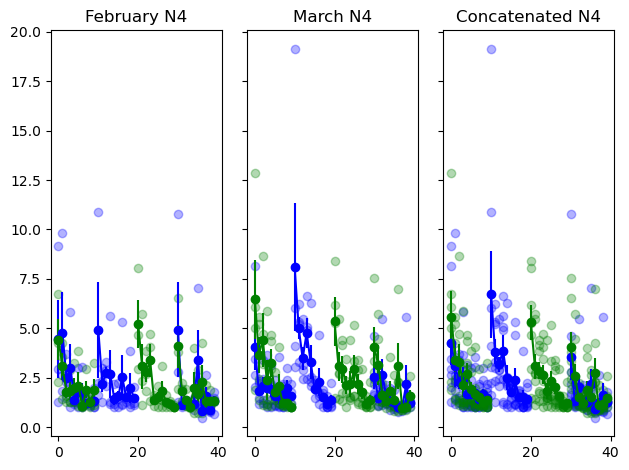

In [4]:
feb_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/FEBRUARY/experiment_organized.yaml'
march_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/MARCH/experiment_organized.yaml'
concat_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/concatenated.yaml'

# Create a figure with all three and share the y axis
plt.figure(figsize=(24, 8))
plt.subplots(1, 3, sharey=True)

plt.subplot(1, 3, 1)
plot_from_yaml(feb_exp_yaml, rat='N4')
plt.title('February N4')

plt.subplot(1, 3, 2)
plot_from_yaml(march_exp_yaml, rat='N4')
plt.title('March N4')

plt.subplot(1, 3, 3)
plot_from_yaml(concat_exp_yaml, rat='N4')
plt.title('Concatenated N4')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Concatenated N1')

<Figure size 2400x800 with 0 Axes>

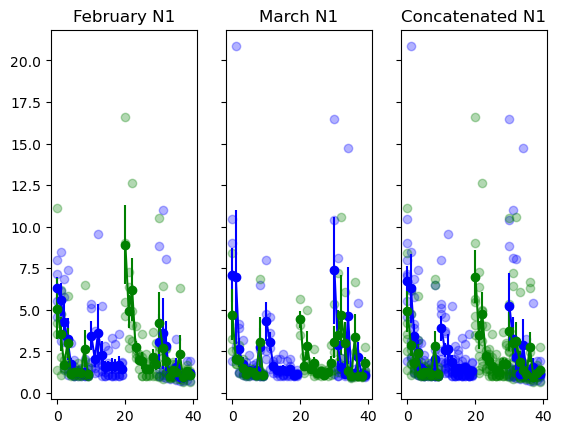

In [5]:
feb_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/FEBRUARY/experiment_organized.yaml'
march_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/MARCH/experiment_organized.yaml'
concat_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/concatenated.yaml'

# Create a figure with all three and share the y axis
plt.figure(figsize=(24, 8))
plt.subplots(1, 3, sharey=True)

plt.subplot(1, 3, 1)
plot_from_yaml(feb_exp_yaml, rat='N1')
plt.title('February N1')

plt.subplot(1, 3, 2)
plot_from_yaml(march_exp_yaml, rat='N1')
plt.title('March N1')

plt.subplot(1, 3, 3)
plot_from_yaml(concat_exp_yaml, rat='N1')
plt.title('Concatenated N1')

Text(0.5, 1.0, 'Concatenated')

<Figure size 2400x800 with 0 Axes>

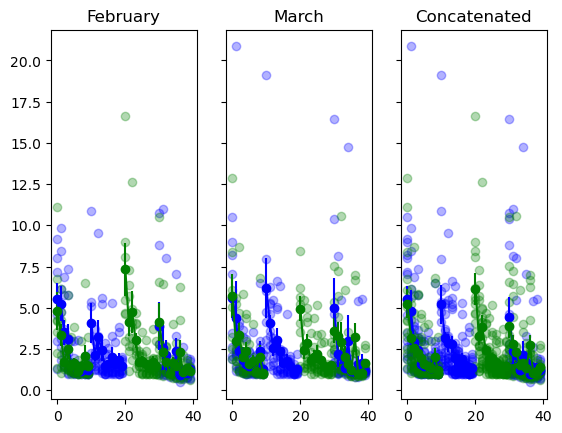

In [6]:
feb_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/FEBRUARY/experiment_organized.yaml'
march_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/MARCH/experiment_organized.yaml'
concat_exp_yaml = r'/Users/nick/Projects/cheeseboardAnalysis/DATA/concatenated.yaml'

# Create a figure with all three and share the y axis
plt.figure(figsize=(24, 8))
plt.subplots(1, 3, sharey=True)

plt.subplot(1, 3, 1)
plot_from_yaml(feb_exp_yaml, rat='')
plt.title('February')

plt.subplot(1, 3, 2)
plot_from_yaml(march_exp_yaml, rat='')
plt.title('March')

plt.subplot(1, 3, 3)
plot_from_yaml(concat_exp_yaml, rat='')
plt.title('Concatenated')